# GC Recent Intrabar Diagnostic

This notebook is a recent-data diagnostic workflow for manual out-of-sample intrabar inspection. It is intentionally separate from the main historical backtest.

Scope limits:

- Data source is `yfinance` (`GC=F`), not the main historical futures dataset.
- Coverage is only the recent 7-day intraday window allowed by the source.
- The replay logic is diagnostic-only and does not redefine the production backtest.
- Independent long/short mode is available here for recent path inspection only.


## 0. Configuration

The defaults are cache-first. Set `force_refresh = True` only when you want to download the latest recent sample from `yfinance`.


In [11]:
import importlib
from pathlib import Path

from IPython.display import display

import gold_breakout_intrabar_recent as intrabar_recent

intrabar_recent = importlib.reload(intrabar_recent)
RecentIntrabarConfig = intrabar_recent.RecentIntrabarConfig
RecentIntrabarReplayConfig = intrabar_recent.RecentIntrabarReplayConfig
recent_intrabar_config_frame = intrabar_recent.recent_intrabar_config_frame
recent_intrabar_replay_config_frame = intrabar_recent.recent_intrabar_replay_config_frame

config = RecentIntrabarConfig(
    ticker="GC=F",
    period="7d",
    interval="1m",
    cache_dir=Path("cache") / "yfinance_intrabar_recent",
    session_gap_threshold_minutes=30,
)

replay_config = RecentIntrabarReplayConfig(
    tp_sl_mode="prior_day_range",
    fixed_ticks=100,
    atr_multiplier_tpsl=2.0,
    k=0.50,
    atr_period=14,
    atr_multiplier=1.5,
    allow_independent_long_short=True,
    close_positions_at_session_end=True,
    frame_step=5,
    animation_interval_ms=120,
)

display(recent_intrabar_config_frame(config))
display(recent_intrabar_replay_config_frame(replay_config))


,parameter,value
0,ticker,GC=F
1,period,7d
2,interval,1m
3,cache_dir,cache\yfinance_intrabar_recent
4,session_gap_threshold_minutes,30


,parameter,value
0,tp_sl_mode,prior_day_range
1,fixed_ticks,100
2,atr_multiplier_tpsl,2.0
3,k,0.5
4,atr_period,14
5,atr_multiplier,1.5
6,allow_independent_long_short,True
7,close_positions_at_session_end,True
8,frame_step,5
9,animation_interval_ms,120


## 1. Imports

The helper module handles cache loading, recent session reconstruction, diagnostic simulation, and replay plotting.


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

build_recent_intrabar_context = intrabar_recent.build_recent_intrabar_context
recent_intrabar_cache_paths = intrabar_recent.recent_intrabar_cache_paths
simulate_intrabar_diagnostic = intrabar_recent.simulate_intrabar_diagnostic
plot_intrabar_session_replay = intrabar_recent.plot_intrabar_session_replay
animate_intrabar_session_replay = intrabar_recent.animate_intrabar_session_replay

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 120


## 2. Load Cached Or Recent Data

This keeps the workflow reproducible and avoids unnecessary downloads during replay work.


In [13]:
force_refresh = False
context = build_recent_intrabar_context(config, force_refresh=force_refresh)
cache_paths = recent_intrabar_cache_paths(config)

display(pd.DataFrame([context["metadata"]]))
display(pd.DataFrame({"cache_key": list(cache_paths.keys()), "path": [str(path) for path in cache_paths.values()]}))
display(context["session_table"])


,source,ticker,period,interval,rows,downloaded_at_utc,ts_min,ts_max,cache_hit
0,yfinance,GC=F,7d,1m,7462,2026-03-31T14:29:32.894110+00:00,2026-03-24T04:00:00+00:00,2026-03-31T14:19:00+00:00,True


,cache_key,path
0,bars_csv,cache\yfinance_intrabar_recent\GC_F_7d_1m.csv
1,metadata_json,cache\yfinance_intrabar_recent\GC_F_7d_1m.meta...


,session_id,session_open_ts,session_close_ts,session_bars,session_open,session_high,session_low,session_close,session_volume,session_date
0,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,1020,4347.399902,4485.600098,4319.899902,4474.899902,173408,2026-03-24 00:00:00+00:00
1,1,2026-03-24 22:00:00+00:00,2026-03-25 20:59:00+00:00,1379,4473.500000,4601.000000,4458.200195,4503.299805,237720,2026-03-24 00:00:00+00:00
2,2,2026-03-25 22:00:00+00:00,2026-03-26 20:59:00+00:00,1379,4508.899902,4541.600098,4348.200195,4376.899902,238665,2026-03-25 00:00:00+00:00
3,3,2026-03-26 22:00:00+00:00,2026-03-27 20:59:00+00:00,1336,4371.799805,4585.299805,4369.100098,4524.299805,202301,2026-03-26 00:00:00+00:00
4,4,2026-03-29 22:10:00+00:00,2026-03-30 20:59:00+00:00,1369,4510.100098,4611.399902,4444.700195,4540.399902,151989,2026-03-29 00:00:00+00:00
5,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,979,4538.899902,4656.100098,4510.000000,4640.600098,107068,2026-03-30 00:00:00+00:00


## 3. Raw Session Preview

These tables make the recent sample auditable before any replay logic runs.


In [14]:
display(context["minute_bars"].head(10))
display(context["hourly_bars"].head(10))


,ts_event,ticker,open,high,low,close,adj_close,volume,session_id,session_open_ts,session_close_ts,session_date,session_open_bar,session_close_bar
0,2026-03-24 04:00:00+00:00,GC=F,4347.399902,4350.899902,4347.200195,4348.899902,4348.899902,0,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,True,False
1,2026-03-24 04:01:00+00:00,GC=F,4350.100098,4352.600098,4349.799805,4351.799805,4351.799805,28,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
2,2026-03-24 04:02:00+00:00,GC=F,4352.500000,4353.600098,4349.299805,4350.500000,4350.500000,37,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
3,2026-03-24 04:03:00+00:00,GC=F,4351.399902,4352.500000,4350.000000,4351.299805,4351.299805,31,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
4,2026-03-24 04:04:00+00:00,GC=F,4351.299805,4353.200195,4351.299805,4352.700195,4352.700195,14,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
5,2026-03-24 04:05:00+00:00,GC=F,4354.000000,4357.700195,4354.000000,4357.500000,4357.500000,21,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
6,2026-03-24 04:06:00+00:00,GC=F,4356.299805,4356.899902,4351.799805,4353.500000,4353.500000,36,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
7,2026-03-24 04:07:00+00:00,GC=F,4353.700195,4354.299805,4349.600098,4349.600098,4349.600098,34,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
8,2026-03-24 04:08:00+00:00,GC=F,4350.299805,4351.200195,4348.500000,4348.500000,4348.500000,20,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
9,2026-03-24 04:09:00+00:00,GC=F,4349.100098,4352.700195,4348.600098,4352.600098,4352.600098,41,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False


,session_id,session_date,ts_event,minute_count,open,high,low,close,adj_close,volume
0,0,2026-03-24 00:00:00+00:00,2026-03-24 04:00:00+00:00,60,4347.399902,4357.700195,4327.000000,4334.000000,4334.000000,2491
1,0,2026-03-24 00:00:00+00:00,2026-03-24 05:00:00+00:00,60,4334.500000,4375.399902,4319.899902,4349.500000,4349.500000,6232
2,0,2026-03-24 00:00:00+00:00,2026-03-24 06:00:00+00:00,60,4348.899902,4406.700195,4345.500000,4403.799805,4403.799805,6113
3,0,2026-03-24 00:00:00+00:00,2026-03-24 07:00:00+00:00,60,4402.500000,4437.600098,4401.000000,4420.200195,4420.200195,8472
4,0,2026-03-24 00:00:00+00:00,2026-03-24 08:00:00+00:00,60,4420.100098,4423.600098,4392.700195,4413.500000,4413.500000,8800
5,0,2026-03-24 00:00:00+00:00,2026-03-24 09:00:00+00:00,60,4413.100098,4432.200195,4397.299805,4427.700195,4427.700195,6689
6,0,2026-03-24 00:00:00+00:00,2026-03-24 10:00:00+00:00,60,4428.000000,4442.899902,4415.200195,4439.700195,4439.700195,7584
7,0,2026-03-24 00:00:00+00:00,2026-03-24 11:00:00+00:00,60,4438.899902,4443.200195,4372.399902,4408.000000,4408.000000,14144
8,0,2026-03-24 00:00:00+00:00,2026-03-24 12:00:00+00:00,60,4408.200195,4427.600098,4361.700195,4378.700195,4378.700195,15189
9,0,2026-03-24 00:00:00+00:00,2026-03-24 13:00:00+00:00,60,4379.000000,4390.700195,4350.399902,4382.500000,4382.500000,20103


## 4. Run Diagnostic Intrabar Simulation

This simulation is minute-based and diagnostic-only. The default here allows independent long/short entries so ambiguous recent path behavior can be inspected directly.


In [15]:
diagnostic = simulate_intrabar_diagnostic(context, replay_config)

display(diagnostic["session_summary"])
display(diagnostic["trade_log"].head(20))
display(diagnostic["event_log"].head(20))
display(diagnostic["frame_state"].head(20))


,session_id,session_date,prev_session_high,prev_session_low,sl_distance_price,allow_independent_long_short,trade_count,entry_count,exit_count,net_pnl_usd
0,1,2026-03-24 00:00:00+00:00,4485.600098,4319.899902,82.850098,True,1,1,1,-920.991584
1,2,2026-03-25 00:00:00+00:00,4601.000000,4458.200195,71.399902,True,1,1,1,1327.376856
2,3,2026-03-26 00:00:00+00:00,4541.600098,4348.200195,96.699951,True,1,1,1,-696.249721
3,4,2026-03-29 00:00:00+00:00,4585.299805,4369.100098,108.099854,True,1,1,1,1792.068332
4,5,2026-03-30 00:00:00+00:00,4611.399902,4444.700195,83.349854,True,1,1,1,-608.957393


,trade_id,session_id,session_date,direction,entry_ts,entry_price,tp_price,initial_sl_price,exit_ts,exit_price,exit_reason,exit_fill_basis,bars_held,pnl_usd,mfe_price,mae_price
0,1,1,2026-03-24 00:00:00+00:00,long,2026-03-24 22:05:00+00:00,4485.700098,4568.550195,4402.850000,2026-03-24 22:07:00+00:00,4476.490182,trail_stop,stop_minus_tick_exit,2,-920.991584,0.900000,9.100000
1,2,2,2026-03-25 00:00:00+00:00,short,2026-03-26 05:52:00+00:00,4458.100195,4386.700293,4529.500098,2026-03-26 06:00:00+00:00,4444.826427,trail_stop,stop_plus_tick_exit,8,1327.376856,23.200293,8.799707
2,3,3,2026-03-26 00:00:00+00:00,long,2026-03-27 14:58:00+00:00,4541.700098,4638.400049,4445.000146,2026-03-27 15:00:00+00:00,4534.737600,trail_stop,stop_minus_tick_exit,2,-696.249721,3.799902,1.700098
3,4,4,2026-03-29 00:00:00+00:00,long,2026-03-30 11:44:00+00:00,4585.399805,4693.499658,4477.299951,2026-03-30 11:52:00+00:00,4603.320488,trail_stop,stop_minus_tick_exit,8,1792.068332,26.000098,0.000000
4,5,5,2026-03-30 00:00:00+00:00,long,2026-03-31 01:24:00+00:00,4611.499902,4694.849756,4528.150049,2026-03-31 01:29:00+00:00,4605.410328,trail_stop,stop_minus_tick_exit,5,-608.957393,3.500098,5.899805


,session_id,session_date,ts_event,trade_id,direction,event_type,event_reason,price
0,1,2026-03-24 00:00:00+00:00,2026-03-24 22:05:00+00:00,1,long,entry,buy_stop_trigger,4485.700098
1,1,2026-03-24 00:00:00+00:00,2026-03-24 22:07:00+00:00,1,long,exit,trail_stop,4476.490182
2,2,2026-03-25 00:00:00+00:00,2026-03-26 05:52:00+00:00,2,short,entry,sell_stop_trigger,4458.100195
3,2,2026-03-25 00:00:00+00:00,2026-03-26 06:00:00+00:00,2,short,exit,trail_stop,4444.826427
4,3,2026-03-26 00:00:00+00:00,2026-03-27 14:58:00+00:00,3,long,entry,buy_stop_trigger,4541.700098
5,3,2026-03-26 00:00:00+00:00,2026-03-27 15:00:00+00:00,3,long,exit,trail_stop,4534.737600
6,4,2026-03-29 00:00:00+00:00,2026-03-30 11:44:00+00:00,4,long,entry,buy_stop_trigger,4585.399805
7,4,2026-03-29 00:00:00+00:00,2026-03-30 11:52:00+00:00,4,long,exit,trail_stop,4603.320488
8,5,2026-03-30 00:00:00+00:00,2026-03-31 01:24:00+00:00,5,long,entry,buy_stop_trigger,4611.499902
9,5,2026-03-30 00:00:00+00:00,2026-03-31 01:29:00+00:00,5,long,exit,trail_stop,4605.410328


,session_id,session_date,ts_event,bar_index,open,high,low,close,buy_stop,sell_stop,long_order_active,short_order_active,long_position_open,short_position_open,long_active_trail_stop,short_active_trail_stop,long_tp,short_tp,event_text
0,1,2026-03-24 00:00:00+00:00,2026-03-24 22:00:00+00:00,0,4473.500000,4482.000000,4472.899902,4477.700195,4485.600098,4319.899902,True,True,False,False,NaN,NaN,NaN,NaN,
1,1,2026-03-24 00:00:00+00:00,2026-03-24 22:01:00+00:00,1,4479.000000,4479.100098,4474.100098,4475.100098,4485.600098,4319.899902,True,True,False,False,NaN,NaN,NaN,NaN,
2,1,2026-03-24 00:00:00+00:00,2026-03-24 22:02:00+00:00,2,4476.799805,4476.799805,4468.899902,4473.299805,4485.600098,4319.899902,True,True,False,False,NaN,NaN,NaN,NaN,
3,1,2026-03-24 00:00:00+00:00,2026-03-24 22:03:00+00:00,3,4473.399902,4475.100098,4471.299805,4471.299805,4485.600098,4319.899902,True,True,False,False,NaN,NaN,NaN,NaN,
4,1,2026-03-24 00:00:00+00:00,2026-03-24 22:04:00+00:00,4,4473.000000,4481.899902,4472.500000,4481.399902,4485.600098,4319.899902,True,True,False,False,NaN,NaN,NaN,NaN,
5,1,2026-03-24 00:00:00+00:00,2026-03-24 22:05:00+00:00,5,4481.200195,4489.399902,4481.100098,4486.399902,4485.600098,4319.899902,False,True,True,False,4402.850000,NaN,4568.550195,NaN,long entry
6,1,2026-03-24 00:00:00+00:00,2026-03-24 22:06:00+00:00,6,4486.600098,4486.600098,4476.600098,4478.700195,4485.600098,4319.899902,False,True,True,False,4476.590182,NaN,4568.550195,NaN,
7,1,2026-03-24 00:00:00+00:00,2026-03-24 22:07:00+00:00,7,4479.200195,4483.000000,4476.200195,4483.000000,4485.600098,4319.899902,False,True,False,False,NaN,NaN,NaN,NaN,long exit: trail_stop
8,1,2026-03-24 00:00:00+00:00,2026-03-24 22:08:00+00:00,8,4482.500000,4485.100098,4481.299805,4483.500000,4485.600098,4319.899902,False,True,False,False,NaN,NaN,NaN,NaN,
9,1,2026-03-24 00:00:00+00:00,2026-03-24 22:09:00+00:00,9,4484.299805,4492.299805,4484.299805,4486.200195,4485.600098,4319.899902,False,True,False,False,NaN,NaN,NaN,NaN,


## 5. Select A Replay Session

Pick the first recent session with at least one closed trade, falling back to the first simulated session if needed.


In [16]:
if diagnostic["session_summary"].empty:
    raise ValueError("No simulated sessions are available for replay.")

trade_sessions = diagnostic["session_summary"].loc[
    diagnostic["session_summary"]["trade_count"].gt(0),
    "session_id",
]
replay_session_id = (
    int(trade_sessions.iloc[0])
    if not trade_sessions.empty
    else int(diagnostic["session_summary"]["session_id"].iloc[0])
)

replay_session_id


1

## 6. Static Session Replay

This plot shows the full minute-by-minute replay state for one recent session.


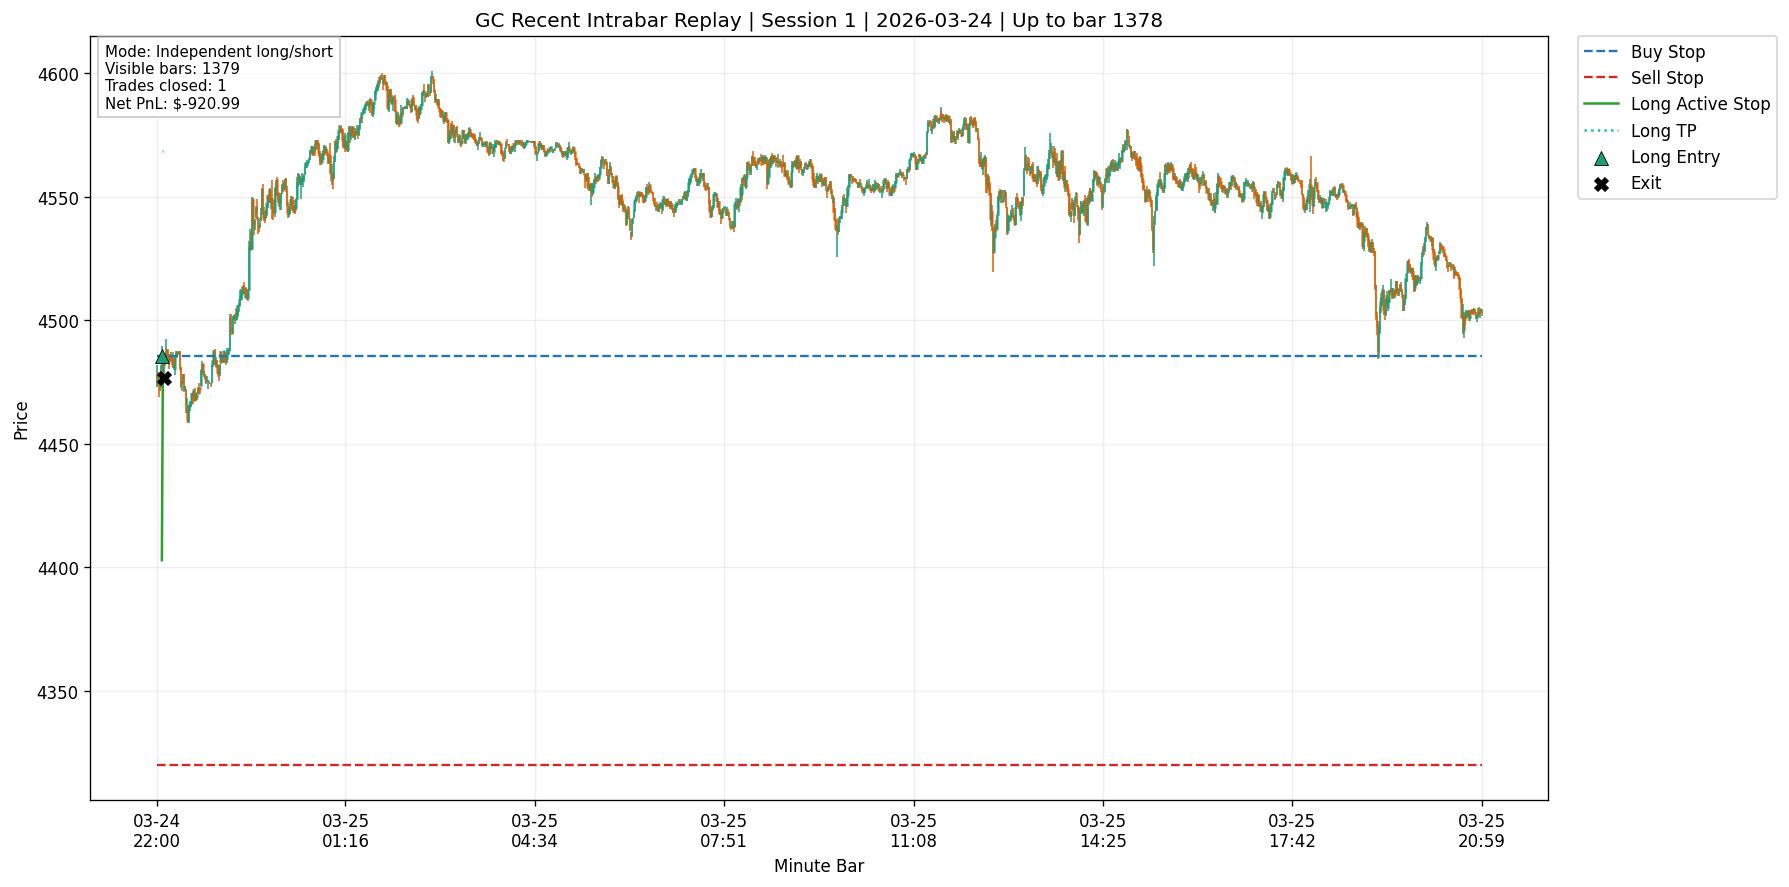

In [17]:
figure = plot_intrabar_session_replay(diagnostic, replay_session_id)
display(figure)
plt.close(figure)


## 7. Animated Session Replay

The animation reveals the intrabar path progressively. This is intended for manual inspection, not performance reporting.


In [ ]:
animation = animate_intrabar_session_replay(diagnostic, replay_session_id)
HTML(animation.to_jshtml())
